<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
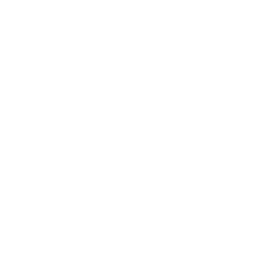
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Trial Adverse Event Coding</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Drug Safety Surveillance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 执行摘要

不良事件数据集到达时使用的是逐字记录的 MedDRA 首选术语，但监管安全性表格是
按系统器官分类（SOC）组织的。本示例构建了一个 PROC FORMAT 值格式，将每个
首选术语映射到其所属 SOC，然后用这一个格式驱动下游的全部制表工作：一个按
治疗组划分 SOC 的 PROC FREQ 交叉表、一个按严重程度划分 SOC 的交叉表，以及
一份严重不良事件汇总。由于映射关系只存在于该格式中，将试验重新编码到新版
MedDRA 只需编辑这一个格式，而不必重写每份报告。ODS OUTPUT 将 SOC 频数捕获
为一个数据集，供下游信号审查使用。

## 数据来源

| 数据源 | 说明 | 记录数 |
|--------|-------------|--------:|
| WORK.AE_RAW | 带有 MedDRA 首选术语的合成不良事件记录 | 100 |
| WORK.RANDOMIZATION | 受试者治疗组分配 | 100 |

运行环境处于未授权模式，因此每张生成的表格上限为 100 条观测。本场景正是
按此上限设计的：从一个包含 12 个术语、典型于肿瘤学试验的 MedDRA 术语集中
抽取 100 个不良事件。

---

In [1]:
/* --------------------------------------------------------
   生成合成不良事件数据集
   MedDRA 首选术语映射到 SOC 类别
   -------------------------------------------------------- */
数据 work.ae_raw;
    长度 aedecod $40 aesev $10;
    调用 streaminit(42);
    数组 pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    循环 i = 1 到 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        如果 pt_idx = 1 那么 aedecod = '恶心';
        否则 如果 pt_idx = 2 那么 aedecod = '头痛';
        否则 如果 pt_idx = 3 那么 aedecod = '呕吐';
        否则 如果 pt_idx = 4 那么 aedecod = '腹泻';
        否则 如果 pt_idx = 5 那么 aedecod = '咳嗽';
        否则 如果 pt_idx = 6 那么 aedecod = '乏力';
        否则 如果 pt_idx = 7 那么 aedecod = '关节痛';
        否则 如果 pt_idx = 8 那么 aedecod = '发热';
        否则 如果 pt_idx = 9 那么 aedecod = '腹痛';
        否则 如果 pt_idx = 10 那么 aedecod = '中性粒细胞减少';
        否则 如果 pt_idx = 11 那么 aedecod = '发热性中性粒细胞减少';
        否则 aedecod = '输注相关反应';
        sev_idx = int(rand('uniform') * 3) + 1;
        如果 pt_idx IN (10, 11) 那么 sev_idx = MAX(sev_idx, 2);
        如果 sev_idx = 1 那么 aesev = '轻度';
        否则 如果 sev_idx = 2 那么 aesev = '中度';
        否则 aesev = '重度';
        aeser = ifc(aesev = '重度' 并且 rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        如果 aestdy > 365 那么 aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        输出;
    结束;
    删除 i pt_idx sev_idx;
运行;


NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.79 seconds
  cpu   1.79 seconds


In [2]:
/* --------------------------------------------------------
   生成受试者随机化分组表
   -------------------------------------------------------- */
数据 work.randomization;
    长度 treatment_arm $20;
    调用 streaminit(43);
    循环 subject_id = 1 到 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        如果 arm_idx = 1 那么 treatment_arm = '试验组';
        否则 如果 arm_idx = 2 那么 treatment_arm = '阳性对照组';
        否则 treatment_arm = '安慰剂组';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        输出;
    结束;
    删除 arm_idx;
    格式 randomization_date date9.;
运行;


NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                                     原始首选术语频率（未映射）                                                      

                                                   The FREQ Procedure

首选术语（PT）                          Frequency    Percent
-------------------------------------------------------
头痛                                       12     12.00
腹泻                                       12     12.00
乏力                                       11     11.00
发热                                       11     11.00
关节痛                                      10     10.00
恶心                                       10     10.00
输注相关反应                                    8      8.00
咳嗽                                        7      7.00
中性粒细胞减少                                   5      5.00
发热性中性粒细胞减少                                5      5.00
腹痛                                        5      5.00
呕吐                                        4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


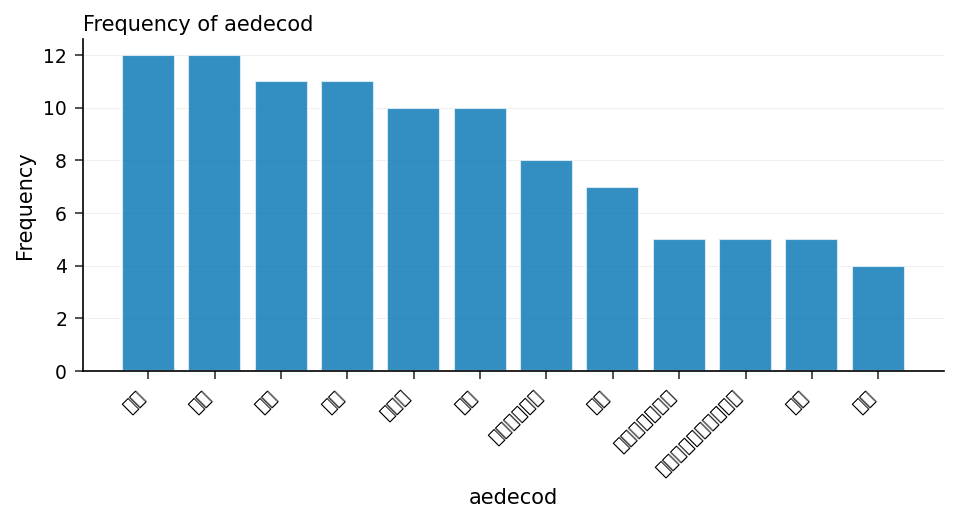

In [3]:
/* --------------------------------------------------------
   映射前的原始首选术语基线频率
   -------------------------------------------------------- */
过程 频率 数据=work.ae_raw ORDER=频率;
    TABLES aedecod / nocum;
    标签 aedecod = '首选术语（PT）';
    标题 '原始首选术语频率（未映射）';
运行;

---

                                                     原始首选术语频率（未映射）                                                      




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


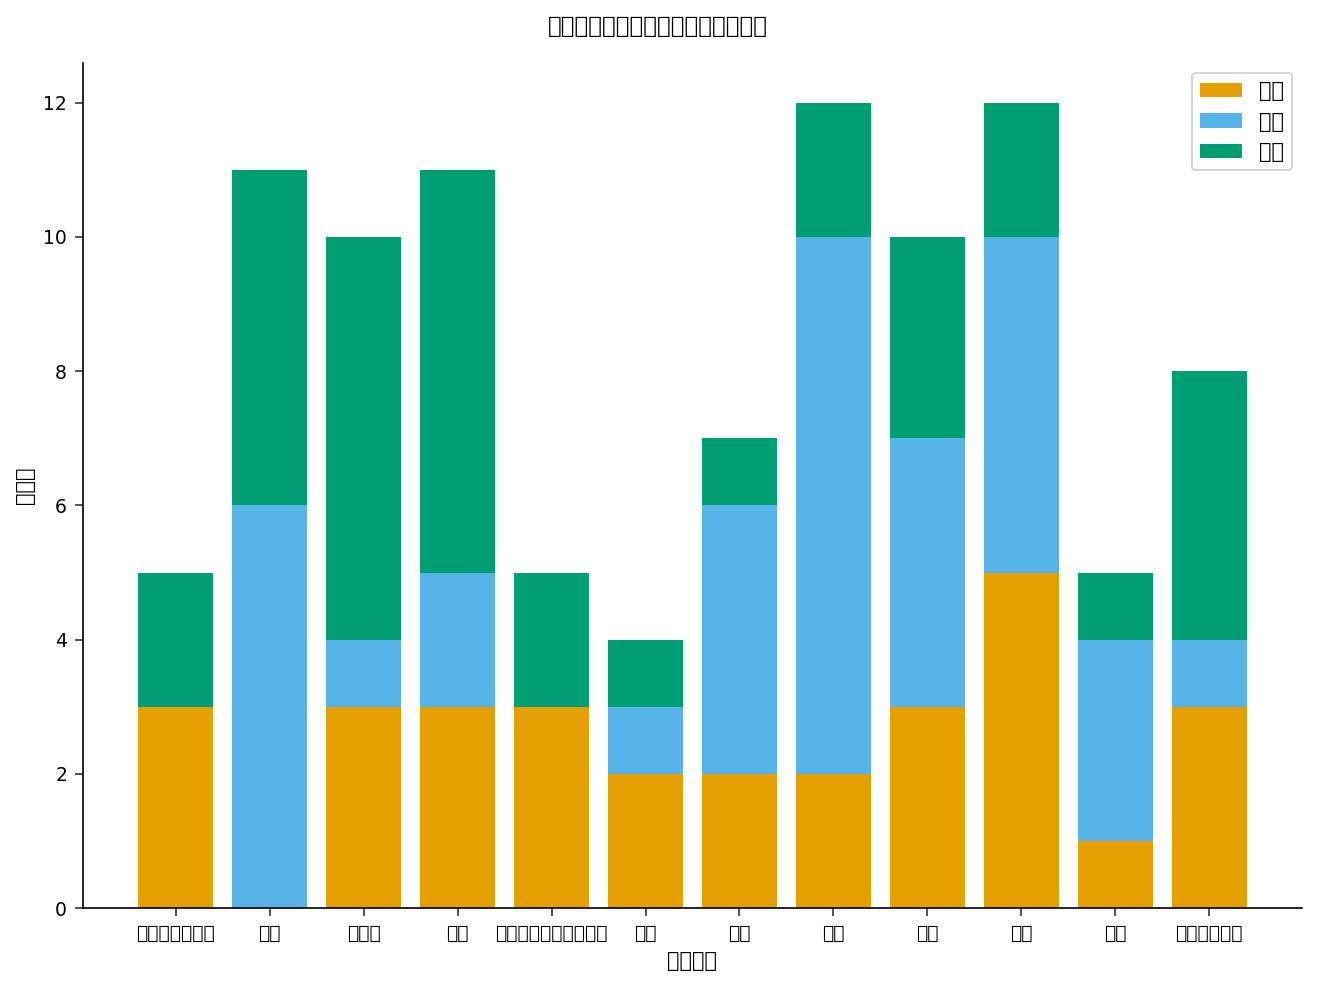

In [4]:
/* --------------------------------------------------------
   各首选术语的不良事件严重程度分布
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS 标签='首选术语' fitpolicy=ROTATE;
    YAXIS 标签='事件数';
    标题 '按首选术语划分的不良事件严重程度';
运行;

---

In [5]:
/* --------------------------------------------------------
   定义 MedDRA 首选术语 -> 系统器官分类（SOC）
   值格式。该格式以首选术语文本为键，
   因此单次 PUT() 调用即可将任意不良事件记录
   编码到其所属 SOC。
   -------------------------------------------------------- */
过程 格式;
    VALUE $pt_to_soc
        '恶心'                 = '胃肠道疾病'
        '呕吐'                 = '胃肠道疾病'
        '腹泻'                 = '胃肠道疾病'
        '腹痛'                 = '胃肠道疾病'
        '头痛'                 = '神经系统疾病'
        '乏力'                 = '全身性疾病'
        '发热'                 = '全身性疾病'
        '咳嗽'                 = '呼吸系统疾病'
        '关节痛'               = '肌肉骨骼系统疾病'
        '中性粒细胞减少'       = '血液及淋巴系统疾病'
        '发热性中性粒细胞减少' = '血液及淋巴系统疾病'
        '输注相关反应'         = '免疫系统疾病'
        OTHER                  = '未编码'
    ;
    VALUE $sev_rank
        '轻度' = '1-轻度'
        '中度' = '2-中度'
        '重度' = '3-重度'
        OTHER  = '9-未知'
    ;
    VALUE $serious_fmt
        'Y' = '严重'
        'N' = '非严重'
    ;
运行;


NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   将不良事件记录与治疗组合并，然后应用 SOC
   格式。PUT(aedecod, $pt_to_soc.) 是唯一需要的映射步骤；
   严重程度与严重性也采用同样方式编码。
   -------------------------------------------------------- */
过程 排序 数据=work.ae_raw; 按照 usubjid; 运行;
过程 排序 数据=work.randomization; 按照 usubjid; 运行;

数据 work.ae_coded;
    长度 soc_class $30 severity_rank $12 serious_flag $10;
    合并 work.ae_raw (IN=a)
          work.randomization (IN=b 保留=usubjid treatment_arm);
    按照 usubjid;
    如果 a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
运行;


NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


                                                 按系统器官分类和治疗组划分的不良事件发生率                                                  

                                                   The FREQ Procedure

Table of 系统器官分类（SOC） by 治疗组

系统器官分类（SOC）                 |           安慰剂组 |            试验组 |          阳性对照组 |           Total
----------------------------+----------------+----------------+----------------+----------------
免疫系统疾病                      |              1 |              1 |              0 |               2
----------------------------+----------------+----------------+----------------+----------------
全身性疾病                       |              3 |              1 |              1 |               5
----------------------------+----------------+----------------+----------------+----------------
胃肠道疾病                       |              2 |              0 |              1 |               3
----------------------------+----------------+----------------+----------------+----------------
血液


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


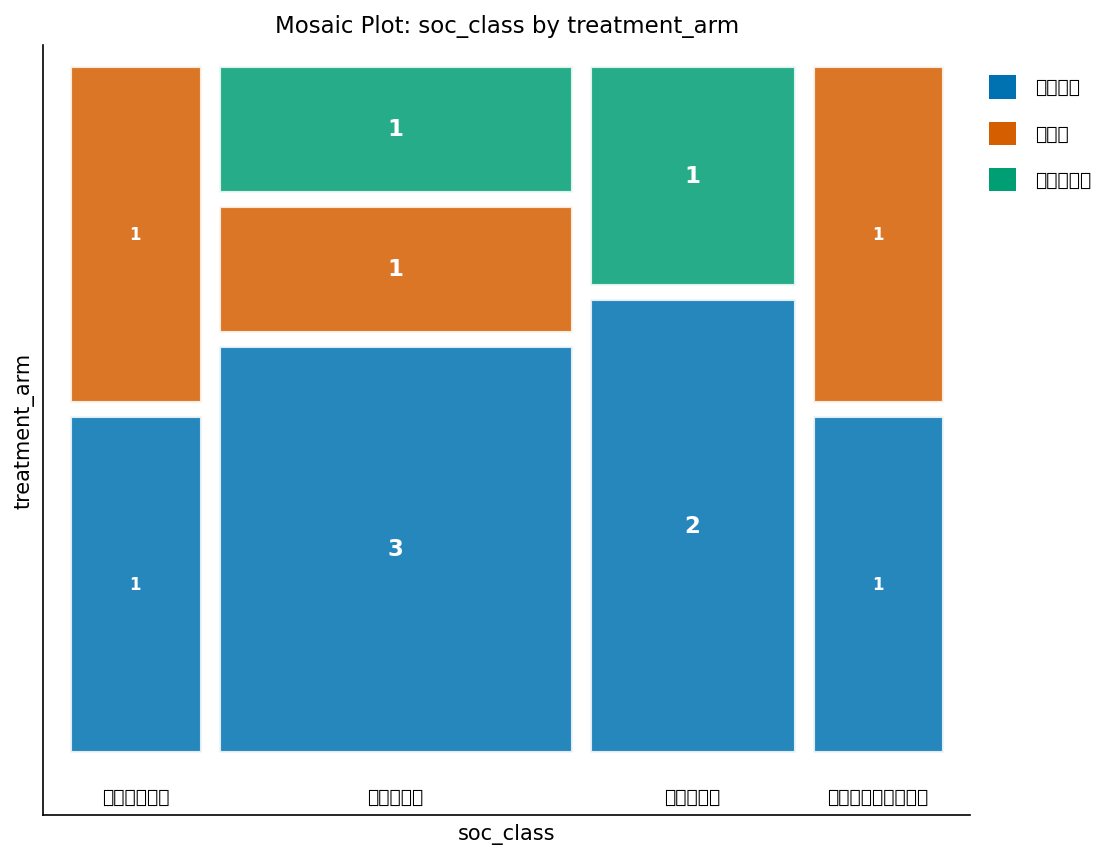

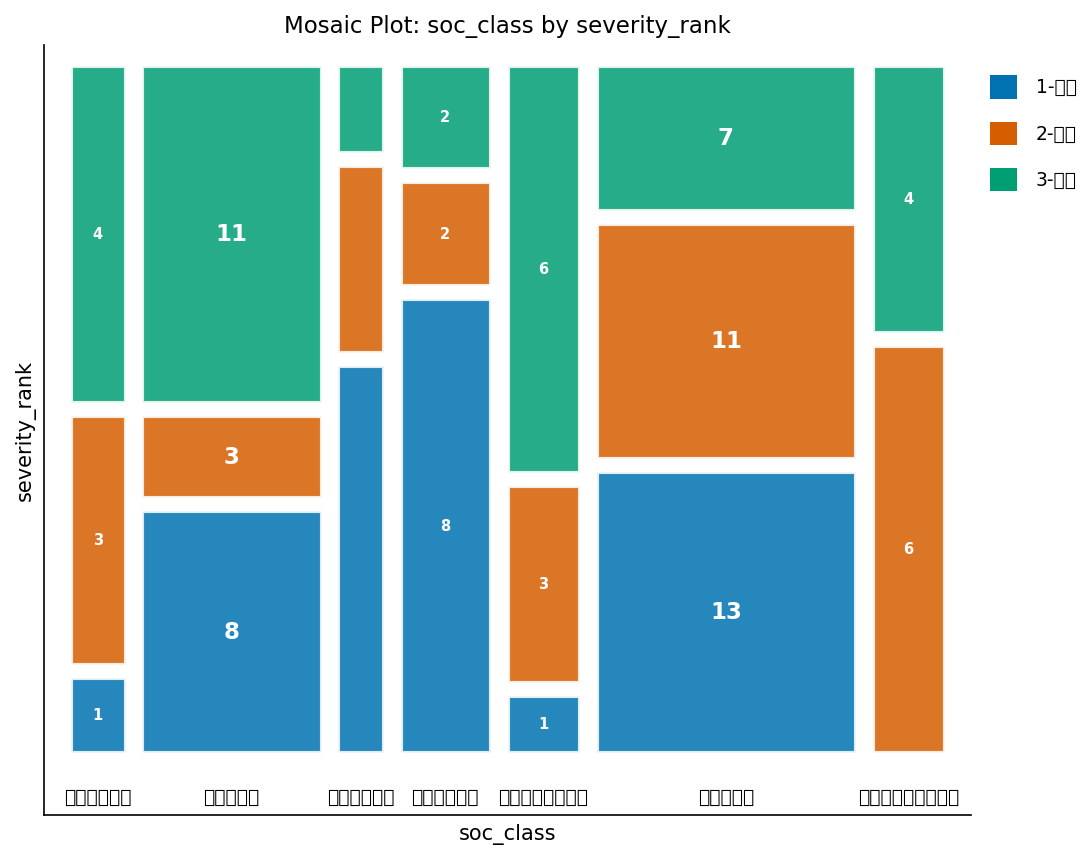

In [7]:
/* --------------------------------------------------------
   按治疗组划分的 SOC 层级频率
   ODS OUTPUT 捕获结果用于信号检测
   -------------------------------------------------------- */
ODS 输出 onewayfreqs=work.soc_freq_table;

过程 频率 数据=work.ae_coded ORDER=频率;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    标签 soc_class = '系统器官分类（SOC）' treatment_arm = '治疗组' severity_rank = '严重程度分级';
    标题 '按系统器官分类和治疗组划分的不良事件发生率';
运行;

ODS 输出 CLOSE;

                                                  按 SOC 和治疗组划分的严重不良事件                                                   

                                                   The FREQ Procedure

Table of 系统器官分类（SOC） by 治疗组

系统器官分类（SOC）                 |           安慰剂组 |            试验组 |          阳性对照组 |           Total
----------------------------+----------------+----------------+----------------+----------------
免疫系统疾病                      |              1 |              0 |              0 |               1
----------------------------+----------------+----------------+----------------+----------------
全身性疾病                       |              1 |              1 |              1 |               3
----------------------------+----------------+----------------+----------------+----------------
Total                       |              2 |              1 |              1 |               4




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


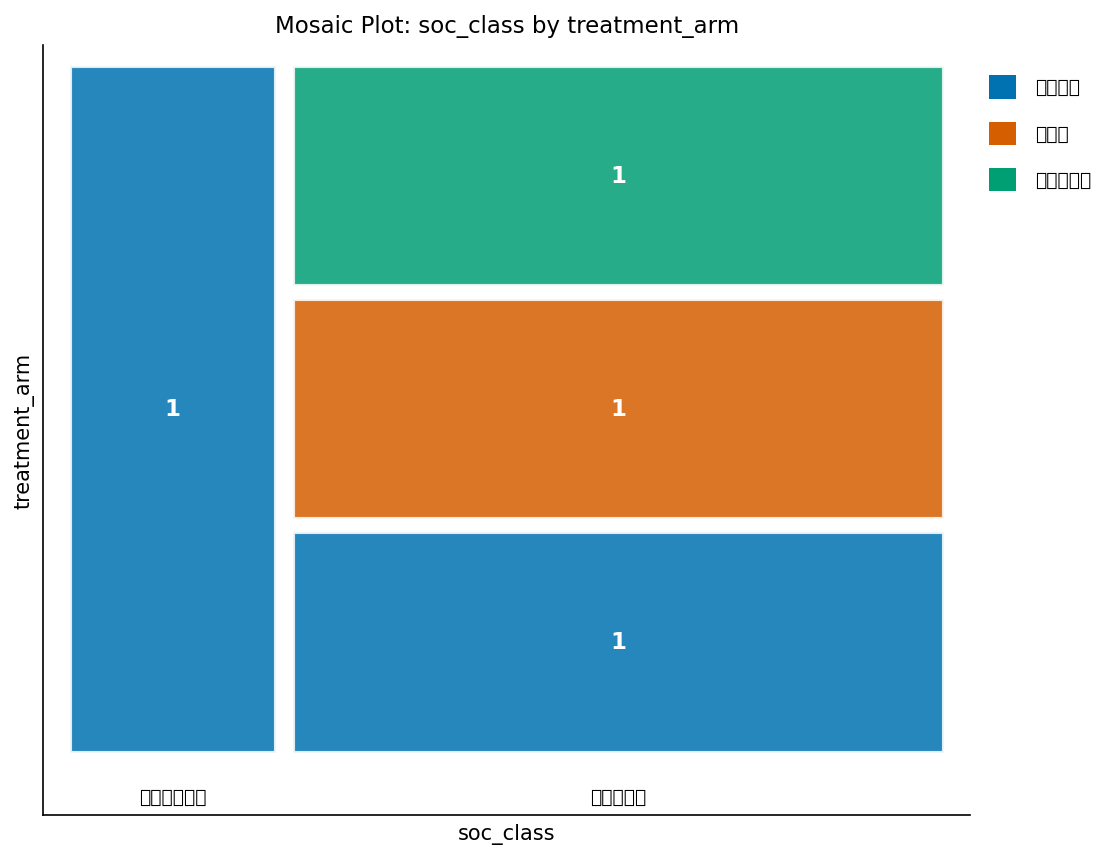

In [8]:
/* --------------------------------------------------------
   用于安全性叙述的按 SOC 划分的严重不良事件汇总
   -------------------------------------------------------- */
过程 频率 数据=work.ae_coded;
    条件 aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    标签 soc_class = '系统器官分类（SOC）' treatment_arm = '治疗组';
    标题 '按 SOC 和治疗组划分的严重不良事件';
运行;

---

### 解读

单一的 `$pt_to_soc` 值格式将全部 100 起不良事件从 12 个逐字记录的 MedDRA
首选术语编码为 7 个系统器官分类（SOC），而下面的每一张表格都由这同一个
格式驱动，无需对数据重新编码。

按 SOC 和严重程度看，**胃肠道疾病**是最常见的分类，共 31 起（100 起中），
其中轻度 13 起、中度 11 起、重度 7 起，其次是**全身性疾病**，共 22 起。
其余分类规模较小：神经系统疾病（12 起）、血液及淋巴系统疾病（10 起）、
肌肉骨骼系统疾病（10 起）、免疫系统疾病（8 起）以及呼吸系统疾病（7 起）。
在全部事件中，严重程度分布为轻度 35 起、中度 30 起、重度 35 起。

仅有 4 起事件被标记为严重（`aeser='Y'`）：全身性疾病 3 起（每个治疗组各
1 起）以及免疫系统疾病 1 起（安慰剂组）。SOC 按治疗组的交叉表是基于 12
起主体匹配到随机化记录的事件构建的，因此各治疗组的计数仅作示意，而非
为组间比较提供统计效力。

关键结论在于 FORMAT 机制本身，而非合成数据的具体数字：由于首选术语到
SOC 的映射完全存放在 PROC FORMAT 中，同一条 `PUT(aedecod, $pt_to_soc.)`
调用就能重新分级整个数据集，升级到新版 MedDRA 词典只需编辑这一个格式，
而不必重写每一份报告。ODS OUTPUT 已将 SOC 频数捕获为 `work.soc_freq_table`
数据集，供下游信号审查使用。

---

In [9]:
/* --------------------------------------------------------
   导出 SOC 编码后的不良事件数据集用于安全性信号审查。
   单一 $pt_to_soc 格式已填充 soc_class，因此导出的
   文件可直接用于下游的 SOC 层级分析。
   -------------------------------------------------------- */
过程 EXPORT 数据=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>